In [2]:
import numpy as np
import pandas as pd
import rasterio
import pyproj
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns
from affine import Affine
import sys
sys.path.insert(0, '../')
from pysheds.grid import Grid

%matplotlib inline

# Generate grid and delineate catchment

In [3]:
FILE = '../data/dem.tif'
grid = Grid.from_raster(FILE)
dem = grid.read_raster(FILE)

# Condition terrain to ensure valid flow direction
dem_filled = grid.fill_pits(dem)
dem_flooded = grid.fill_depressions(dem_filled)
dem_conditioned = grid.resolve_flats(dem_flooded)

In [4]:
         #N    NE    E    SE    S    SW    W    NW
dirmap = (64,  128,  1,   2,    4,   8,    16,  32)

In [5]:
# Generate Flow Direction
fdir = grid.flowdir(dem_conditioned, dirmap=dirmap)

# Specify pour point
x, y = -97.294167, 32.73750

# Delineate the catchment
catch = grid.catchment(x=x, y=y, fdir=fdir, dirmap=dirmap, 
                       recursionlimit=15000, xytype='label', nodata_out=0)

In [6]:
grid.clip_to(catch)

In [7]:
catch_view = grid.view(catch)

# View data specified in different crs

In [ ]:
# Path to external NLCD data
# Importing and visualizing impervious data
# Data source: https://www.pasda.psu.edu/download/usgs/NLCD2011/ 
# Data file: nlcd_2011_impervious_2011_edition_2014_10_10.zip
nlcd_path = '../data/impervious_data.img'

# Read the raster into a variable using the current grid window
terrain = grid.read_raster(nlcd_path, window=grid.bbox, window_crs=grid.crs)

/home/juanguerrero09/dev/pysheds/examples/../pysheds/io.py:137: UserWarning: No `nodata` value detected. Defaulting to 0.
  warnings.warn('No `nodata` value detected. Defaulting to 0.')


In [9]:
print(f"Grid CRS: {grid.crs.srs}")
print(f"Terrain CRS: {terrain.crs.srs}")

Grid CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Terrain CRS: PROJCS["Albers Conical Equal Area",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["meters",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


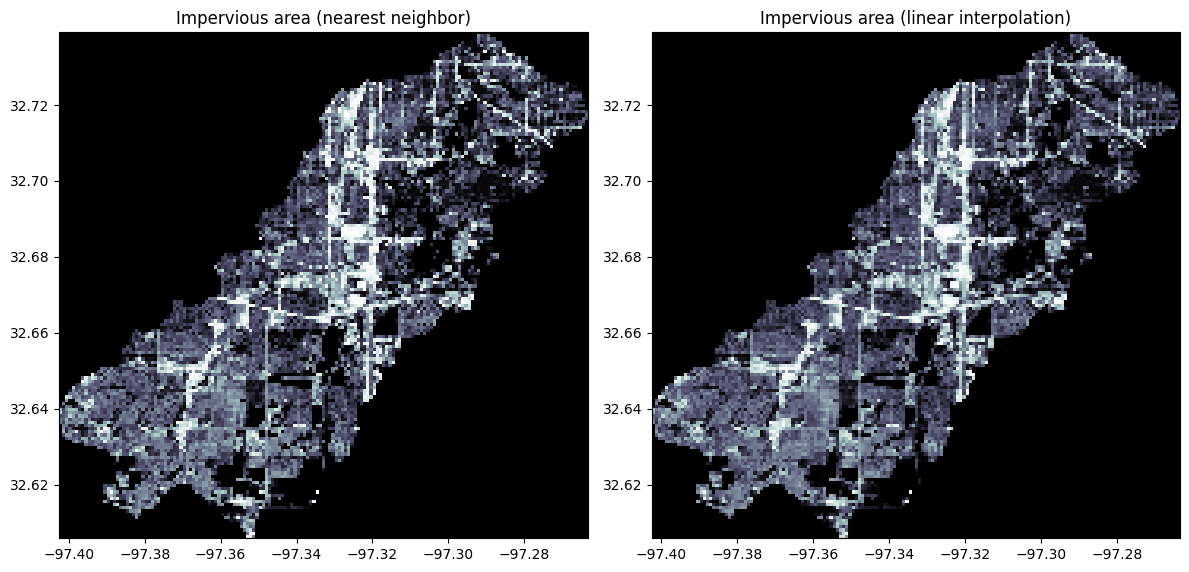

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Nearest Neighbor (Best for categorical data/classes)
ax[0].imshow(grid.view(terrain, interpolation='nearest', dtype=np.float32), cmap='bone',
             extent=grid.extent, zorder=1, vmin=0, vmax=100)
ax[0].set_title('Impervious area (nearest neighbor)')

# Linear Interpolation (Smoother for continuous data)
ax[1].imshow(grid.view(terrain, interpolation='linear', dtype=np.float32), cmap='bone',
             extent=grid.extent, zorder=1, vmin=0, vmax=100)
ax[1].set_title('Impervious area (linear interpolation)')

plt.tight_layout()
plt.show()

# Convert grid coordinate reference system

In [11]:
# WGS 84: Geographic
old_crs = grid.crs.srs

# NAD83 / Texas Centric Albers Equal Area: Projected
new_crs = 'epsg:3083'

# Create a transformer to calculate the new coordinates in meters
transformer = pyproj.Transformer.from_crs(old_crs, new_crs, always_xy=True)

In [12]:
# 1. Project the catch data (it remains congruent in pixel space)
projected_catch = catch_view.copy()

# 2. Get the lat/lon coordinates from the current viewfinder
coords = grid.viewfinder.coords

# 3. Transform the coordinates into meters
# coords[:, 1] is x (longitude), coords[:, 0] is y (latitude)
proj_x, proj_y = transformer.transform(coords[:, 1], coords[:, 0])

# 4. Stack them for the final plotting logic
projected_coords = np.column_stack([proj_y, proj_x])

# View catchment in converted CRS

In [14]:
# Verify that the array elements match before and after coordinate transformation
np.allclose(catch_view, projected_catch)

True

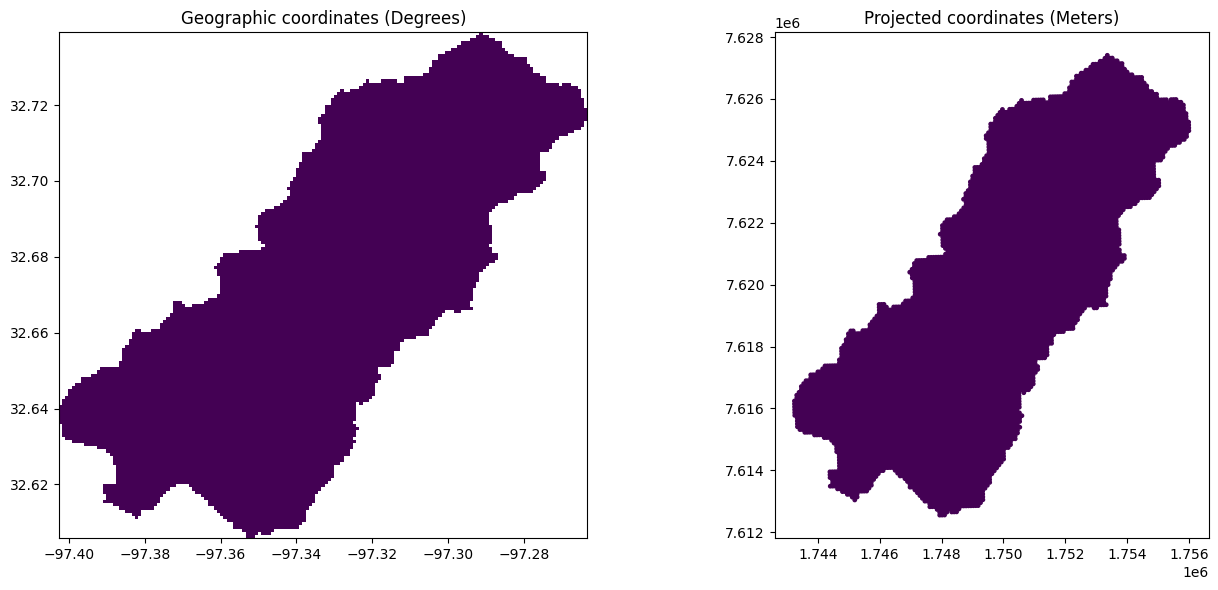

In [15]:
# Plot the catchment
image_arr = np.where(catch_view != 0, catch_view, np.nan)
image_arr2 = projected_catch[projected_catch != 0]

# Filter coordinates based on the catchment mask
y_pts = projected_coords[:, 0][(projected_catch != 0).ravel()]
x_pts = projected_coords[:, 1][(projected_catch != 0).ravel()]

fig, ax = plt.subplots(1, 2, figsize=(14,6))

# Left plot: Degrees
ax[0].imshow(image_arr, extent=grid.extent, zorder=1, cmap='viridis')
ax[0].set_title('Geographic coordinates (Degrees)')
ax[0].set_aspect('equal')

# Right plot: Meters
ax[1].scatter(x_pts, y_pts, c=image_arr2.ravel(), s=6, cmap='viridis')
ax[1].set_title('Projected coordinates (Meters)')
ax[1].set_aspect('equal')

plt.tight_layout()
plt.show()

In [16]:
# Debugging the projected object
print(f"Projected Catch Shape: {projected_catch.shape}")
print(f"Projected Catch Max Value: {projected_catch.max()}")
print(f"Projected Catch CRS: {projected_catch.crs}")
print(f"Projected Catch Affine:\n{projected_catch.affine}")
print(f"Number of catchment pixels found: {np.count_nonzero(projected_catch != 0)}")

Projected Catch Shape: (160, 167)
Projected Catch Max Value: 1
Projected Catch CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Projected Catch Affine:
| 0.00, 0.00,-97.40|
| 0.00,-0.00, 32.74|
| 0.00, 0.00, 1.00|
Number of catchment pixels found: 11408
